<a href="https://colab.research.google.com/github/FarsusDasdana/llm_reasoner_simple/blob/main/LangGraph_Reasoner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Env.

In [ ]:
!pip -q install langchain-core langchain-community langgraph langchain-google-genai duckduckgo-search

In [ ]:
!pip show langchain langchain-core langchain-community langgraph langchain-google-genai duckduckgo-search

Name: langchain
Version: 0.3.7
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.10/dist-packages
Requires: aiohttp, async-timeout, langchain-core, langchain-text-splitters, langsmith, numpy, pydantic, PyYAML, requests, SQLAlchemy, tenacity
Required-by: langchain-community
---
Name: langchain-core
Version: 0.3.15
Summary: Building applications with LLMs through composability
Home-page: https://github.com/langchain-ai/langchain
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.10/dist-packages
Requires: jsonpatch, langsmith, packaging, pydantic, PyYAML, tenacity, typing-extensions
Required-by: langchain, langchain-community, langchain-google-genai, langchain-openai, langchain-text-splitters, langgraph, langgraph-checkpoint
---
Name: langchain-community
Version: 0.3.5
Summary: Community contributed LangChain integrations.
Home-page: h

# Simple Flow

In [ ]:
import os
from google.colab import userdata

os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

## Components

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash",
                             temperature=0)

In [ ]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

# search tools
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

In [ ]:
tools = [add, multiply, divide, search]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

## Graph

In [ ]:
# Node
def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

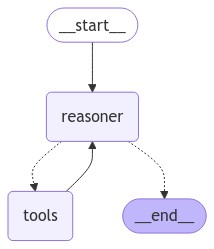

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="What is 2 times Brad Pitt's age?")]
messages = react_graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times Brad Pitt's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (33f91337-bc85-49f2-a61e-41cbca443c6a)
 Call ID: 33f91337-bc85-49f2-a61e-41cbca443c6a
  Args:
    query: Brad Pitt age
================================= Tool Message =================================
Name: duckduckgo_search

Actor Brad Pitt is known the movies 'Fight Club,' 'The Curious Case of Benjamin Button,' and 'Moneyball.' Read about his age, girlfriend, children, and more. Brad Pitt is an American actor born on December 18, 1963, in Shawnee, Oklahoma. He has starred in various films, including Thelma & Louise, Fight Club, Ocean's trilogy, and Once Upon a Time…in Hollywood, for which he won an Oscar. Brad Pitt marked his 60th birthday with a celebration at Mother Wolf in Los Angeles this week. One onlooker says the actor 'looked super happy' at the party, 

# Manuel way of adding custom tools

https://colab.research.google.com/drive/14ncV0nviLcP9IDzmFSRGSXb7Bgpz212v?usp=sharing#scrollTo=QtczHZq39HKG